In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def display(img, camp='gray'):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap='gray')

In [3]:
# Medina Blur
# Grayscale
# Binary Threshold
# Find Contours

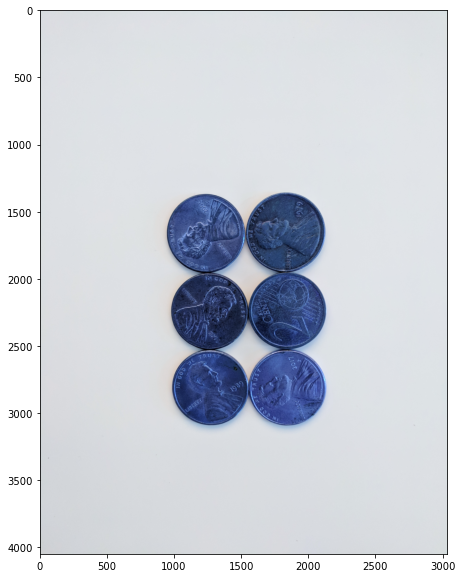

In [4]:
sep_coins=cv2.imread('../DATA/pennies.jpg')
display(sep_coins)

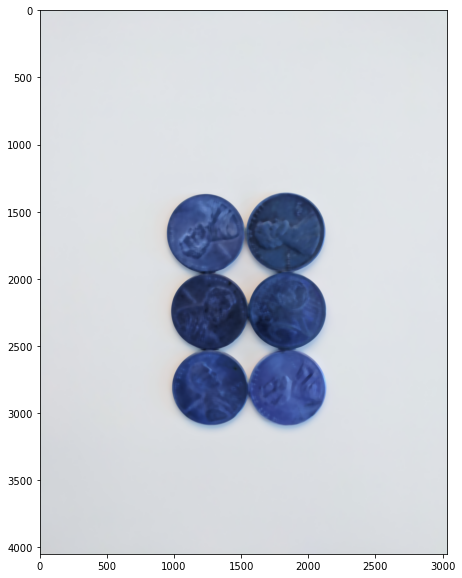

In [5]:
#Medina Blur

sep_blur=cv2.medianBlur(sep_coins,25)
display(sep_blur)

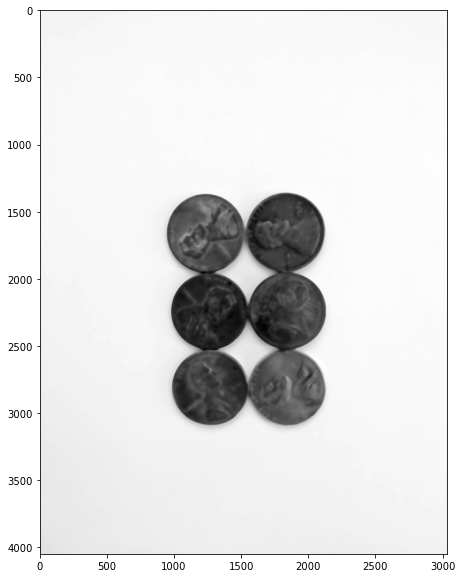

In [6]:
gray_sep_coins=cv2.cvtColor(sep_blur, cv2.COLOR_BGR2GRAY)

display(gray_sep_coins)

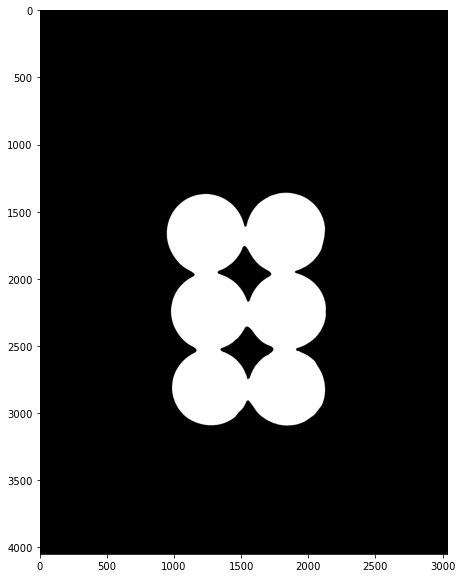

In [7]:
ret, sep_thresh=cv2.threshold(gray_sep_coins,160,255,cv2.THRESH_BINARY_INV)
display(sep_thresh)

In [8]:
contours, hierarchy= cv2.findContours(sep_thresh.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE )



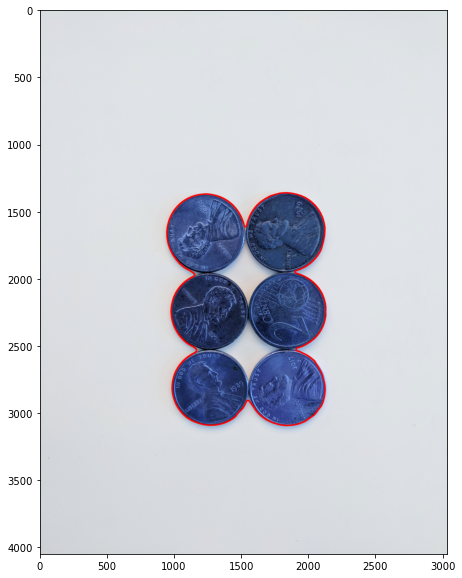

In [9]:
for i in range(len(contours)):

    if hierarchy[0][i][3]==-1:
        cv2.drawContours(sep_coins, contours, i, (255,0,0), 10 )
        
display(sep_coins)

# Watershed Algorithm

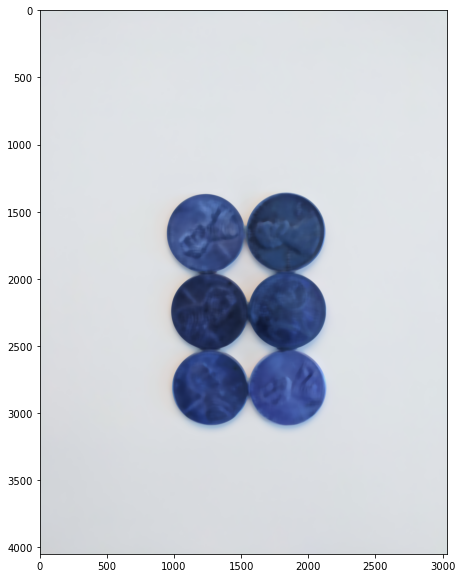

In [10]:
img=cv2.imread('../DATA/pennies.jpg')
img=cv2.medianBlur(img,35)
display(img)

In [11]:
# Blur, gray, Threshold (For thresholding use Otsu's method)
img=cv2.medianBlur(img,35)
gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh=cv2.threshold(gray,0,255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)



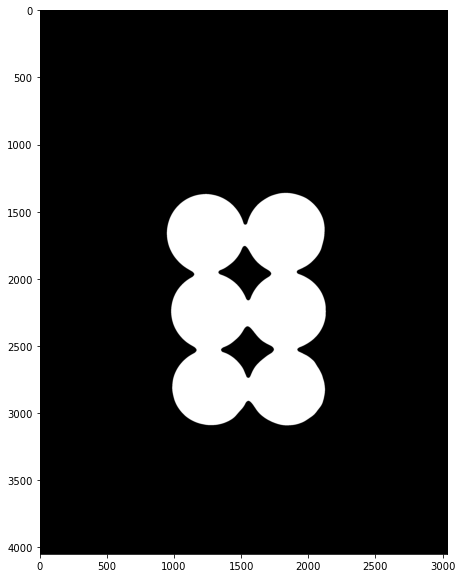

In [12]:
display(thresh)

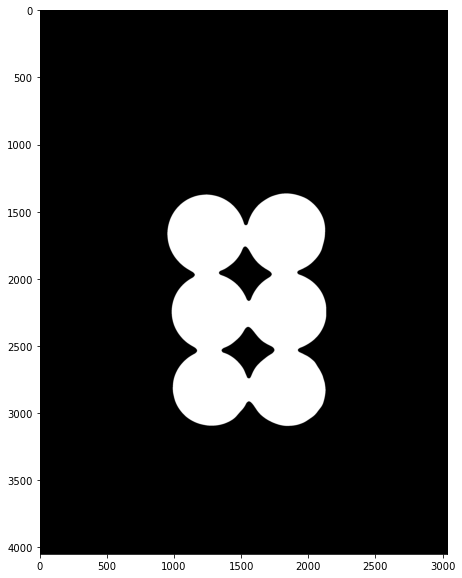

In [13]:
# NOISE REMOVEL
kernel = np.ones((4,4), np.uint8)
opening=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel=kernel, iterations=4)
display(opening)

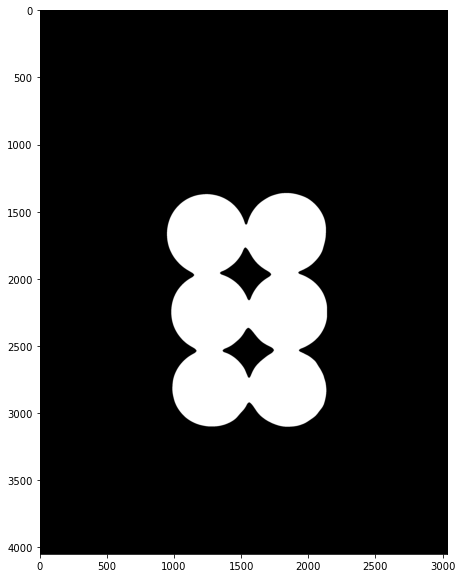

In [14]:
sure_bg=cv2.dilate(opening,kernel,iterations=3)
display(sure_bg)

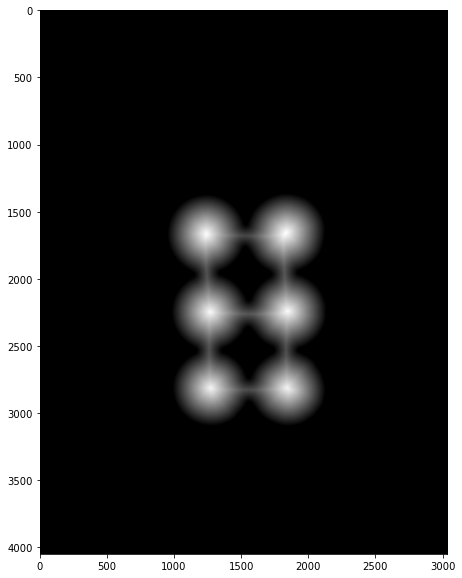

In [15]:
# Distance transform
dist_transform=cv2.distanceTransform( opening, cv2.DIST_L2, 5 )
display(dist_transform)

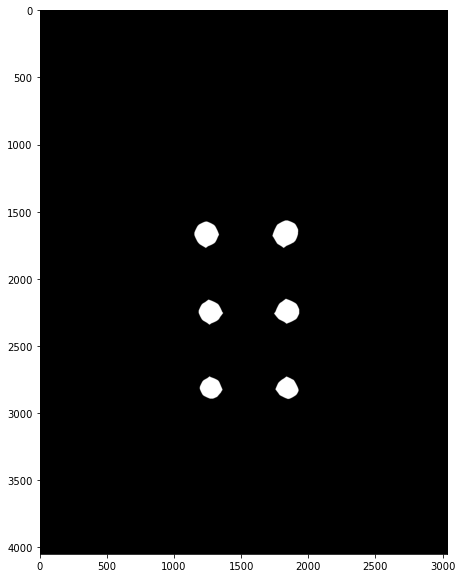

In [16]:
ret, sure_fg= cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)
display(sure_fg)

In [17]:
sure_fg=np.uint8(sure_fg)



In [18]:
unknown=cv2.subtract(sure_bg, sure_fg)

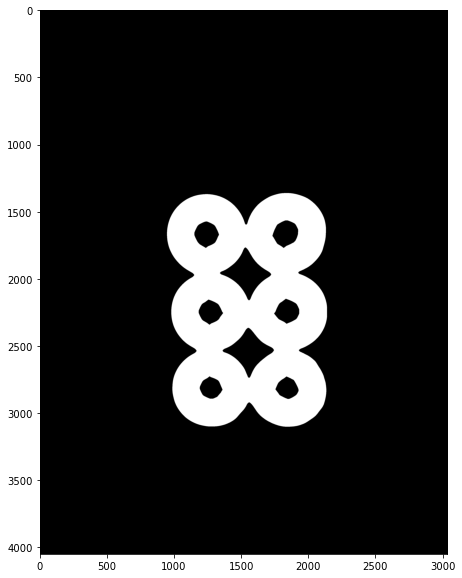

In [19]:
display(unknown)

### Creating label markers

In [22]:
ret, markers=cv2.connectedComponents(sure_fg)

In [23]:
markers=markers+1

In [24]:
markers[unknown==255]=0

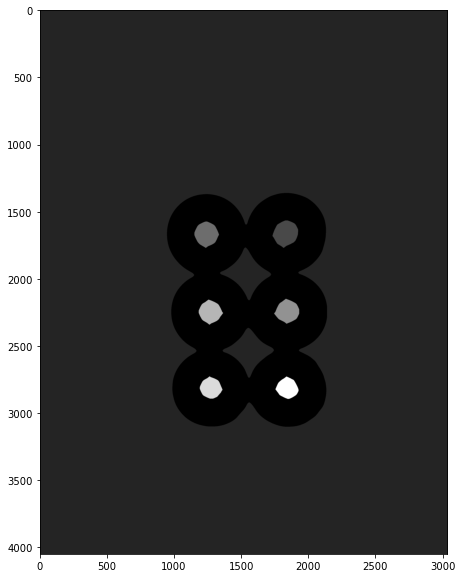

In [25]:
display(markers)

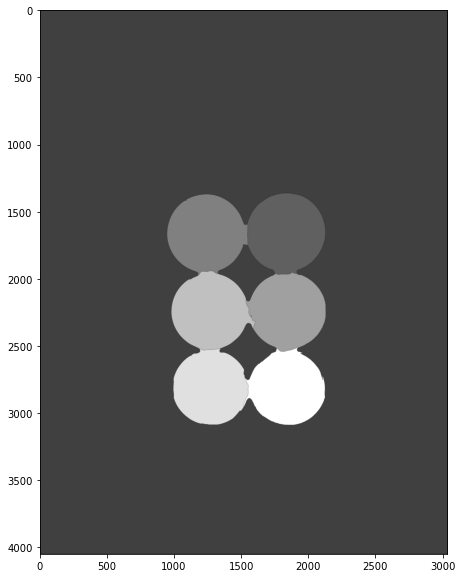

In [26]:
markers=cv2.watershed(img,markers)
display(markers)

In [28]:
contours, hierarchy= cv2.findContours(markers.copy(), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE )

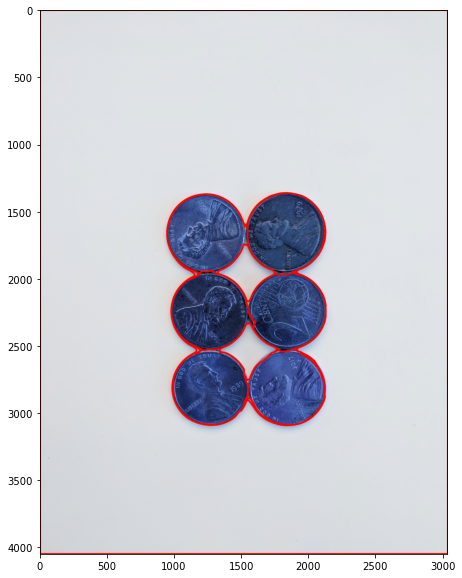

In [29]:
for i in range(len(contours)):

    if hierarchy[0][i][3]==-1:
        cv2.drawContours(sep_coins, contours, i, (255,0,0), 10 )
        
display(sep_coins)